In [47]:
with open('data_f22.csv', 'r') as archivo:
    lineas = [line.rstrip() for line in archivo]

v_indicated = [] # [knot]
v_true = []      # [knot]
pressure = []    # [psi]
temperature = [] # [°C]
dens_ratio = []  # [-]
rho = []         # [kg/m3]
altitude = []    # [km]
lightspeed = []  # [m/s]


for i in lineas[1:-1]:
    v_indicated.append(float(i.split(',')[1]))
    v_true.append(float(i.split(',')[2]))
    pressure.append(float(i.split(',')[14])*0.491154)
    temperature.append(float(i.split(',')[15]))
    dens_ratio.append(float(i.split(',')[17]))
    rho.append(float(i.split(',')[17])*1.225)
    altitude.append(float(i.split(',')[31]))
    lightspeed.append((1.4 * 287.0528 * (float(i.split(',')[15]) + 273.15))**.5)

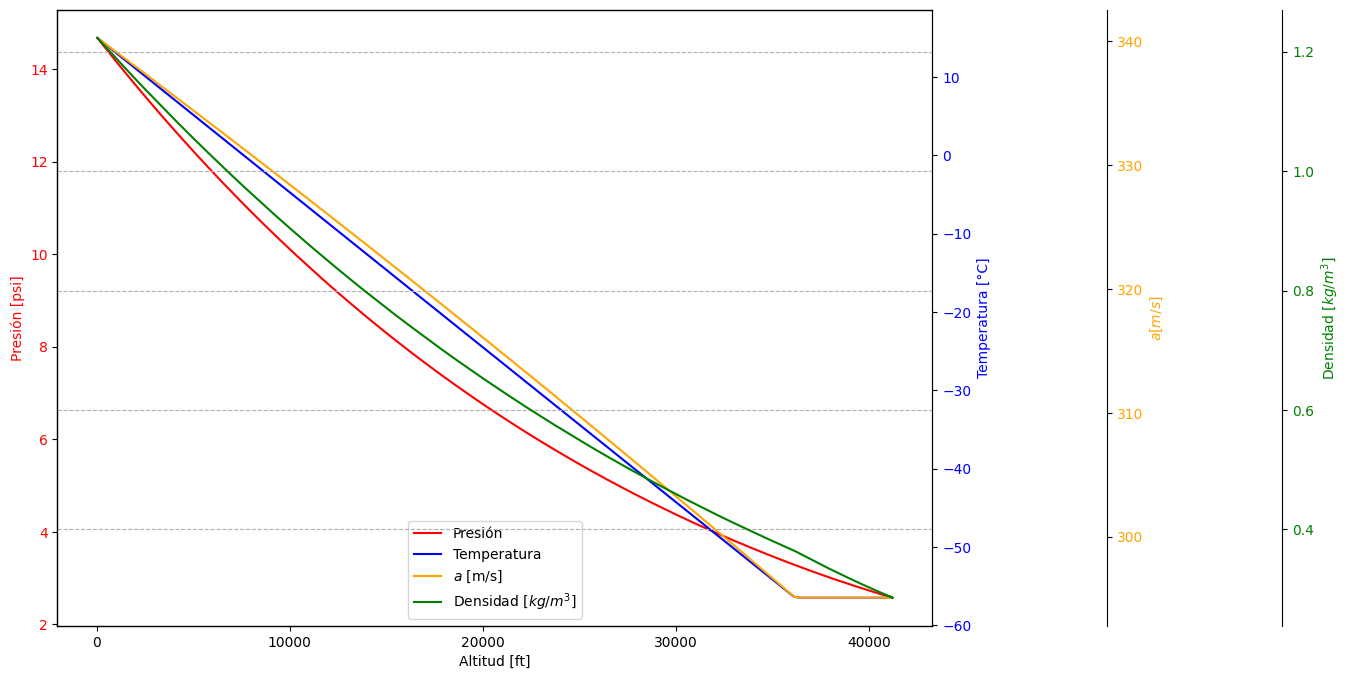

In [50]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots()
fig.subplots_adjust(right=0.75) 

ax2 = ax1.twinx()

ax3 = ax1.twinx()
ax3.spines.right.set_position(("axes", 1.20))

ax4 = ax1.twinx()
ax4.spines.right.set_position(("axes", 1.40))

color1, color2, color3 = 'crimson', 'royalblue', 'forestgreen'

p1, = ax1.plot(altitude, pressure, color='red', label="Presión")
p2, = ax2.plot(altitude, temperature, color='blue', label="Temperatura")
p3, = ax3.plot(altitude, lightspeed, color='orange', label="$a$ [m/s]")
p4, = ax4.plot(altitude, rho, color='green', label = 'Densidad $[kg/m^3]$')

ax1.set_xlabel("Altitud [ft]")
ax1.set_ylabel("Presión [psi]", color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2.set_ylabel("Temperatura [°C]", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

ax3.set_ylabel("$a   [m/s]$", color='orange')
ax3.tick_params(axis='y', labelcolor='orange')

ax4.set_ylabel("Densidad $[kg/m^3]$", color='green')
ax4.tick_params(axis='y', labelcolor='green')

lines = [p1, p2, p3, p4]
ax1.legend(lines, [l.get_label() for l in lines], loc="lower center")

plt.rcParams['figure.figsize'] = (14,8)

plt.grid(linestyle='--')
plt.show()
